In [1]:
using Pkg
Pkg.activate("TASEP")
Pkg.instantiate()
include("./modules/transcription.jl")

  Activating project at `C:\Users\ChemeGrad2021\Documents\Braatz Group\MRNA Synthesis\Published code\IVTratelaw\TASEP`


plotparametricellipse (generic function with 1 method)

In [2]:
#Sequence parameters for Fluc construct
N_all = 2078;
N_plasmid = 4352;
(p_base,modellist,modelnamelist) = getbaseparams(N_all);
flucparams = [1227.1586717676387 9.965583900597288 53.08834752918987];

In [3]:
function getic(D,P,thinparams)
    (k_i,α,K_MD) = thinparams
    (rate,ic) = quasisteadyrate_analytic_general(k_i, K_MD, α, 0, 0, 0, D, P)
    return ic*D
end

function loopbackdsRNAfraction(scalingparam, D, P, thinparams, R)
    ic = getic(D,P,thinparams)
    return scalingparam*R/(D-ic)
end

function antisensedsRNAfraction(scalingparam, D, P, thinparams, R)
    ic = getic(D,P,thinparams)
    return scalingparam*D/(D-ic)
end

antisensedsRNAfraction (generic function with 1 method)

In [4]:
conversiondsRNAflucdata = Matrix(CSV.read("data/dsRNA/conversion_dsRNA_Fluc.csv",DataFrame))
P = 192
D = 9.13
Rrange = LinRange(0,1,200)
loopbackdsRNA = [loopbackdsRNAfraction(0.016, D, P, flucparams, R) for R in Rrange]
antisensedsRNA = [antisensedsRNAfraction(0.0018, D, P, flucparams, R) for R in Rrange]
conversionplot = plot(Rrange,[loopbackdsRNA,antisensedsRNA],label = ["RNA templated model" "DNA templated model"],xlabel = "Fractional Extent of Reaction",ylabel = "dsRNA Fraction",size = (400,400))
scatter!(conversiondsRNAflucdata[:,1],conversiondsRNAflucdata[:,2],xerror = conversiondsRNAflucdata[:,3], yerror = conversiondsRNAflucdata[:,4],color = :black,label = "")

DNAdsRNAflucdata = Matrix(CSV.read("data/dsRNA/DNA_dsRNA_Fluc.csv",DataFrame))
P = 192
Drange = LinRange(1,500,200)
loopbackdsRNA = [loopbackdsRNAfraction(0.016, D, P, flucparams, 1) for D in Drange]
antisensedsRNA = [antisensedsRNAfraction(0.0018, D, P, flucparams, 1) for D in Drange]
DNAplot = plot(Drange,[loopbackdsRNA,antisensedsRNA],label = ["RNA templated model" "DNA templated model"],yscale = :log,xscale = :log,xlabel = "DNA added (nM)",ylabel = "dsRNA Fraction")
scatter!(DNAdsRNAflucdata[:,1],DNAdsRNAflucdata[:,2], yerror = DNAdsRNAflucdata[:,3],color = :black,label = "")
masterplot = plot(conversionplot,DNAplot, size = (600,300), bottommargin = 5mm, dpi = 2000,grid = false)
savefig(masterplot,"./figures/pubfigs/dsRNAmain.png")
masterplot

┌ Warning: scale log is unsupported with Plots.GRBackend().
│ Choose from: [:identity, :ln, :log10, :log2]
└ @ Plots C:\Users\ChemeGrad2021\.julia\packages\Plots\HyyIK\src\args.jl:1584
┌ Warning: scale log is unsupported with Plots.GRBackend().
│ Choose from: [:identity, :ln, :log10, :log2]
└ @ Plots C:\Users\ChemeGrad2021\.julia\packages\Plots\HyyIK\src\args.jl:1584
┌ Warning: scale log is unsupported with Plots.GRBackend().
│ Choose from: [:identity, :ln, :log10, :log2]
└ @ Plots C:\Users\ChemeGrad2021\.julia\packages\Plots\HyyIK\src\args.jl:1584
┌ Warning: scale log is unsupported with Plots.GRBackend().
│ Choose from: [:identity, :ln, :log10, :log2]
└ @ Plots C:\Users\ChemeGrad2021\.julia\packages\Plots\HyyIK\src\args.jl:1584


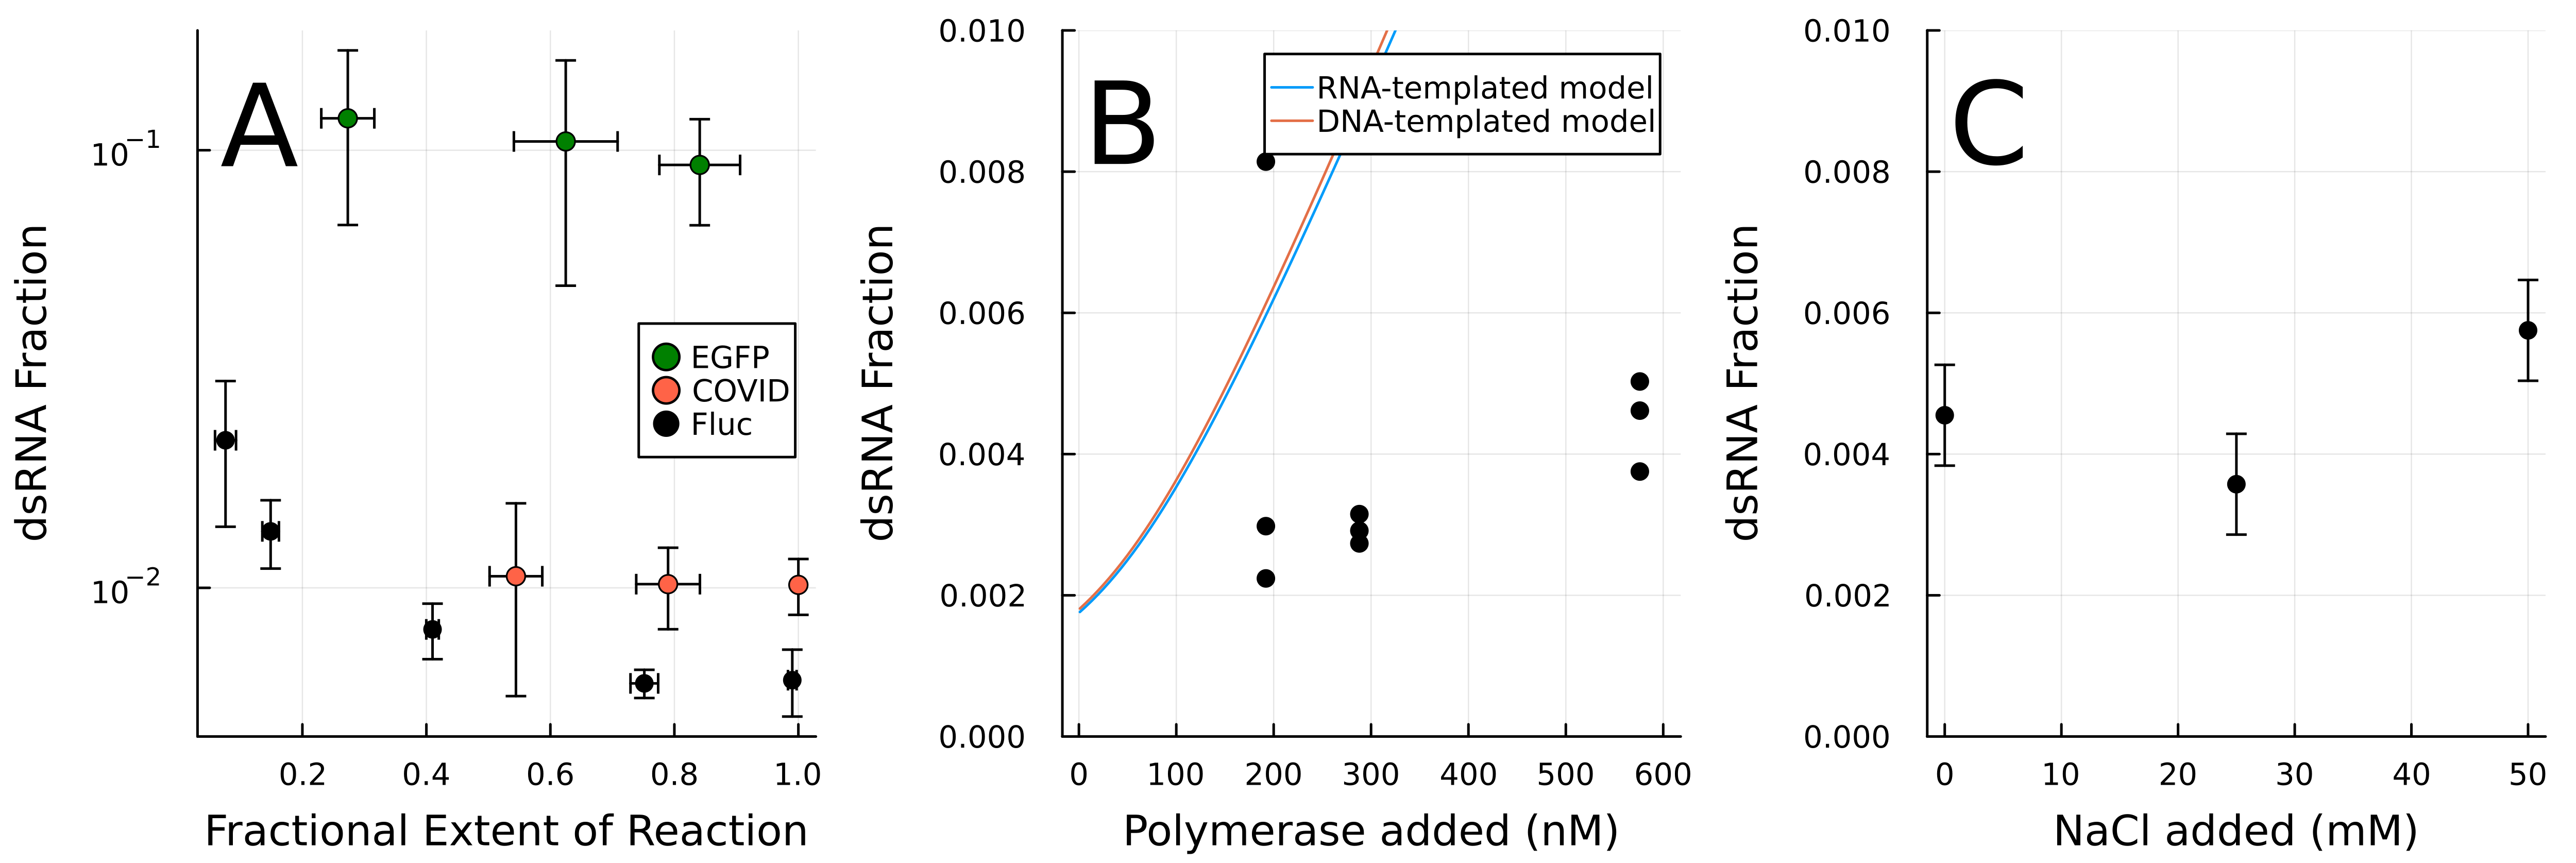

In [5]:
conversiondsRNAEGFPdata = Matrix(CSV.read("data/dsRNA/conversion_dsRNA_EGFP.csv",DataFrame))
conversiondsRNACOVIDdata = Matrix(CSV.read("data/dsRNA/conversion_dsRNA_COVID.csv",DataFrame))

conversionplot = plot(xlabel = "Fractional Extent of Reaction",ylabel = "dsRNA Fraction",size = (350,350),yscale = :log,legend = :right)
scatter!(conversiondsRNAEGFPdata[:,1],conversiondsRNAEGFPdata[:,2],xerror = conversiondsRNAEGFPdata[:,3], yerror = conversiondsRNAEGFPdata[:,4],color = :green,label = "EGFP")
scatter!(conversiondsRNACOVIDdata[:,1],conversiondsRNACOVIDdata[:,2],xerror = conversiondsRNACOVIDdata[:,3], yerror = conversiondsRNACOVIDdata[:,4],color = :tomato,label = "COVID")
scatter!(conversiondsRNAflucdata[:,1],conversiondsRNAflucdata[:,2],xerror = conversiondsRNAflucdata[:,3], yerror = conversiondsRNAflucdata[:,4],color = :black,label = "Fluc")

PolymerasedsRNAflucdata = Matrix(CSV.read("data/dsRNA/Polymerase_dsRNA_Fluc.csv",DataFrame))
D = 9.134
Prange = LinRange(1,600,100)
loopbackdsRNA = [loopbackdsRNAfraction(0.016, D, P, flucparams, 1) for P in Prange]
antisensedsRNA = [antisensedsRNAfraction(0.0018, D, P, flucparams, 1) for P in Prange]
pltP = plot(Prange,[loopbackdsRNA,antisensedsRNA],label = ["RNA-templated model" "DNA-templated model"],xlabel = "Polymerase added (nM)",ylabel = "dsRNA Fraction",ylims = (0,0.01))
scatter!(PolymerasedsRNAflucdata[:,1],PolymerasedsRNAflucdata[:,2],color = :black,label = "")

saltdsRNAflucdata = Matrix(CSV.read("data/dsRNA/salt_dsRNA_Fluc.csv",DataFrame))
pltS = plot(xlabel = "NaCl added (mM)",ylabel = "dsRNA Fraction",ylims = (0,0.01))
scatter!(saltdsRNAflucdata[:,1],saltdsRNAflucdata[:,2],yerror = saltdsRNAflucdata[:,3], color = :black,label = "")

PSplot = plot(conversionplot,pltP,pltS, size = (1000,335),layout = (1,3),bottommargin = 5mm,leftmargin = 5mm,dpi = 500)
fontsize = 30
annotate!(sp=1,[(relativex(0.1; sp=1), relativey(0.6; sp=1), text("A",fontsize))],z_order = :front)
annotate!(sp=2,[(relativex(0.1; sp=2), relativey(0.87; sp=2), text("B",fontsize))],z_order = :front)
annotate!(sp=3,[(relativex(0.1; sp=3), relativey(0.87; sp=3), text("C",fontsize))],z_order = :front)
savefig(PSplot,"./figures/pubfigs/dsRNASI.png")
PSplot